In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/programmer3/malnutrition-risk-in-ethiopian-children/malnutrition_children_ethiopia.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/programmer3/malnutrition-risk-in-ethiopian-children/malnutrition_children_ethiopia.csv")

In [3]:
df

,ID,Age (months),Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Stunting,Underweight,Overweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
0,1,31,Male,Amhara,Higher,Middle,84.1,19.2,1,1,0,1,1,1,1,At_Risk
1,2,38,Female,Tigray,Higher,Middle,91.0,6.3,0,0,0,0,1,1,0,Normal
2,3,7,Female,SNNPR,Secondary,Middle,61.4,5.8,1,1,1,1,1,0,1,Normal
3,4,7,Female,Amhara,Higher,Low,103.1,12.9,1,0,1,1,0,1,0,Normal
4,5,0,Male,Tigray,No education,High,78.9,7.4,0,0,0,0,1,1,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4093,4094,9,Male,Oromia,Primary,High,75.2,15.7,1,1,1,0,0,0,1,Normal
4094,4095,3,Female,Oromia,No education,Middle,73.8,10.6,0,1,0,1,0,1,0,At_Risk
4095,4096,39,Female,Tigray,No education,Middle,63.9,18.0,1,1,0,0,0,0,0,At_Risk
4096,4097,56,Male,Addis Ababa,Primary,High,83.8,11.6,0,0,0,1,0,1,1,At_Risk


In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df.isnull().sum()

ID                        0
Age (months)              0
Gender                    0
Region                    0
Mother_Education          0
Household_Wealth_Index    0
Height_cm                 0
Weight_kg                 0
Stunting                  0
Underweight               0
Overweight                0
Anemia                    0
Malaria                   0
Diarrhea                  0
TB                        0
Nutrition_Status          0
dtype: int64

In [6]:
df.shape

(4098, 16)

In [7]:
df['Nutrition_Status'].value_counts()

Nutrition_Status
Normal          2030
At_Risk         1238
Malnourished     830
Name: count, dtype: int64

In [8]:
df=df.drop(["ID"],axis=1)

In [9]:
df.head()

,Age (months),Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Stunting,Underweight,Overweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
0,31,Male,Amhara,Higher,Middle,84.1,19.2,1,1,0,1,1,1,1,At_Risk
1,38,Female,Tigray,Higher,Middle,91.0,6.3,0,0,0,0,1,1,0,Normal
2,7,Female,SNNPR,Secondary,Middle,61.4,5.8,1,1,1,1,1,0,1,Normal
3,7,Female,Amhara,Higher,Low,103.1,12.9,1,0,1,1,0,1,0,Normal
4,0,Male,Tigray,No education,High,78.9,7.4,0,0,0,0,1,1,0,Normal


In [10]:
df = df.drop(["Region"], axis =1)

In [11]:
df["Gender"].value_counts()

Gender
Male      2066
Female    2032
Name: count, dtype: int64

In [12]:
df.head()

,Age (months),Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Stunting,Underweight,Overweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
0,31,Male,Higher,Middle,84.1,19.2,1,1,0,1,1,1,1,At_Risk
1,38,Female,Higher,Middle,91.0,6.3,0,0,0,0,1,1,0,Normal
2,7,Female,Secondary,Middle,61.4,5.8,1,1,1,1,1,0,1,Normal
3,7,Female,Higher,Low,103.1,12.9,1,0,1,1,0,1,0,Normal
4,0,Male,No education,High,78.9,7.4,0,0,0,0,1,1,0,Normal


In [13]:
df['BMI'] = df['Weight_kg'] / (df['Height_cm']/100)**2

In [14]:
df = df.drop(['Underweight', 'Overweight'], axis=1)

In [15]:
df.head()

,Age (months),Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Stunting,Anemia,Malaria,Diarrhea,TB,Nutrition_Status,BMI
0,31,Male,Higher,Middle,84.1,19.2,1,1,1,1,1,At_Risk,27.146212
1,38,Female,Higher,Middle,91.0,6.3,0,0,1,1,0,Normal,7.607777
2,7,Female,Secondary,Middle,61.4,5.8,1,1,1,0,1,Normal,15.384779
3,7,Female,Higher,Low,103.1,12.9,1,1,0,1,0,Normal,12.135911
4,0,Male,No education,High,78.9,7.4,0,0,1,1,0,Normal,11.887149


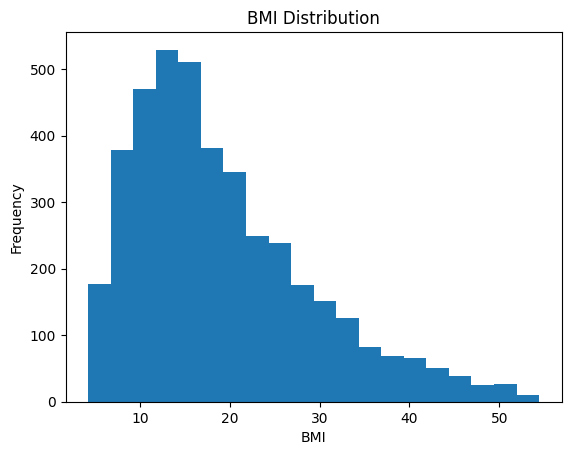

In [16]:
plt.figure()
plt.hist(df['BMI'], bins=20)

plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("BMI Distribution")

plt.show()

In [17]:
# Count outliers
outliers = df[(df['BMI'] < 10) | (df['BMI'] > 40)]

print("Number of outlier rows:", len(outliers))

Number of outlier rows: 868


In [18]:
df.shape

(4098, 13)

In [19]:
df = df[(df['BMI'] >= 8) & (df['BMI'] <= 45)]

In [20]:
df.shape

(3641, 13)

In [21]:
df["Nutrition_Status"].value_counts()

Nutrition_Status
Normal          1805
At_Risk         1104
Malnourished     732
Name: count, dtype: int64

In [22]:
# Gender
df['Gender'] = df['Gender'].map({
    'Male': 1,
    'Female': 0
})

# Mother Education
df['Mother_Education'] = df['Mother_Education'].map({
    'No education': 0,
    'Primary': 1,
    'Secondary': 2,
    'Higher': 3
})

# Household Wealth Index
df['Household_Wealth_Index'] = df['Household_Wealth_Index'].map({
    'Low': 0,
    'Middle': 1,
    'High': 2
})

In [23]:
df['Disease_Score'] = df[['Anemia','Malaria','Diarrhea','TB']].sum(axis=1)

In [24]:
def final_status(row):
    
    # 🔴 Severe
    if (row['BMI'] < 14) or \
       (row['Disease_Score'] >= 2 and row['Stunting'] == 1):
        return "Severe"
    
    # 🟠 Moderate
    elif (row['BMI'] < 18) or \
         (row['Stunting'] == 1) or \
         (row['Disease_Score'] == 1):
        
        # downgrade if poor background
        if row['Mother_Education'] <= 1 or row['Household_Wealth_Index'] == 0:
            return "Moderate"
        else:
            return "Moderate"
    
    # 🟢 Normal
    else:
        # upgrade only if good conditions
        if row['Mother_Education'] >= 2 and row['Household_Wealth_Index'] >= 1:
            return "Normal"
        else:
            return "Moderate"

In [25]:
df['Target'] = df.apply(final_status, axis=1)

In [26]:
df['Target'] = df['Target'].map({
    'Severe': 0,
    'Moderate': 1,
    'Normal': 2
})

In [27]:
df.head()

,Age (months),Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Stunting,Anemia,Malaria,Diarrhea,TB,Nutrition_Status,BMI,Disease_Score,Target
0,31,1,3,1,84.1,19.2,1,1,1,1,1,At_Risk,27.146212,4,0
2,7,0,2,1,61.4,5.8,1,1,1,0,1,Normal,15.384779,3,0
3,7,0,3,0,103.1,12.9,1,1,0,1,0,Normal,12.135911,2,0
4,0,1,0,2,78.9,7.4,0,0,1,1,0,Normal,11.887149,2,0
5,6,1,2,0,75.0,11.3,1,0,0,1,0,Normal,20.088889,1,1


In [28]:
df= df.drop(['Nutrition_Status'],axis=1)

In [29]:
df.head()

,Age (months),Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Stunting,Anemia,Malaria,Diarrhea,TB,BMI,Disease_Score,Target
0,31,1,3,1,84.1,19.2,1,1,1,1,1,27.146212,4,0
2,7,0,2,1,61.4,5.8,1,1,1,0,1,15.384779,3,0
3,7,0,3,0,103.1,12.9,1,1,0,1,0,12.135911,2,0
4,0,1,0,2,78.9,7.4,0,0,1,1,0,11.887149,2,0
5,6,1,2,0,75.0,11.3,1,0,0,1,0,20.088889,1,1


In [30]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [31]:
# Features & Target
X = df.drop(['Target','BMI'], axis=1)   # or 'Target' if you used custom
y = df['Target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [34]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")
    

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.7901
Decision Tree Accuracy: 0.9657
Random Forest Accuracy: 0.9767
KNN Accuracy: 0.6653
SVM Accuracy: 0.6447
AdaBoost Accuracy: 0.7668
Gradient Boosting Accuracy: 0.9849


## Optimized RandomForest Training pipeline
This section uses SMOTE, feature engineering, and Hyperparameter Tuning to maximize model accuracy.

In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("Starting Data Optimization Pipeline...")

# 1. Load Data
df = pd.read_csv('malnutrition_children_ethiopia (1).csv')
print(f"Data shape initially: {df.shape}")

# 2. Feature Engineering
# Create BMI feature
df['BMI'] = df['Weight_kg'] / ((df['Height_cm'] / 100) ** 2)

# Create Disease Context Score
df['Disease_Context_Score'] = 0
for col in ['Malaria', 'Diarrhea', 'TB', 'Anemia']:
    if col in df.columns:
        df['Disease_Context_Score'] += df[col].apply(lambda x: 1 if str(x).lower().strip() == 'yes' else 0)

# Drop ID variable if exists
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# 3. Handle Missing values and Encode Categorical Variables
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = [c for c in categorical_cols if c != 'Nutrition_Status']  # Target to be handled separately

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Simple imputation by mode for categorical
    df[col].fillna(df[col].mode()[0], inplace=True)
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Map Target manually or with LabelEncoder
if 'Nutrition_Status' in df.columns:
    target_le = LabelEncoder()
    df['Nutrition_Status'].fillna(df['Nutrition_Status'].mode()[0], inplace=True)
    df['Target'] = target_le.fit_transform(df['Nutrition_Status'])
    df.drop('Nutrition_Status', axis=1, inplace=True)
    le_dict['Target'] = target_le
else:
    raise ValueError("Target 'Nutrition_Status' not found!")

# Numeric Imputation (Median)
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# 4. Define X and y
X = df.drop(['Target'], axis=1)
y = df['Target']

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Pre-SMOTE Training Class distribution:")
print(y_train.value_counts())

# 6. Apply SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Post-SMOTE Training Class distribution:")
print(y_train_sm.value_counts())

# 7. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# 8. Train & Hyperparameter Tune RandomForest
print("Starting RandomizedSearchCV for RandomForest...")
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf = RandomForestClassifier(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, 
                               n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=None)
rf_random.fit(X_train_scaled, y_train_sm)

best_rf = rf_random.best_estimator_

# 9. Evaluate Best Model
y_pred = best_rf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Optimized Random Forest Accuracy: {acc * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_le.classes_))

# 10. Save Assets
with open('malnutrition_rf_v2_optimized.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

with open('malnutrition_scaler_v2_optimized.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Saved highly-optimized model to 'malnutrition_rf_v2_optimized.pkl'")
print("Saved Scaler to 'malnutrition_scaler_v2_optimized.pkl'")
